In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import open_clip
import faiss

from sklearn.metrics.pairwise import cosine_similarity

In [20]:
import sys
print(sys.executable)


C:\Users\Alumo\anaconda3\envs\py12\python.exe


In [21]:
import sys
!{sys.executable} -m pip install faiss-cpu

In [16]:
import faiss
print("FAISS Installed Successfully!")

FAISS Installed Successfully!


In [10]:
import sys
!{sys.executable} -m pip install open_clip_torch

  Using cached open_clip_torch-3.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached huggingface_hub-1.21.0-py3-none-any.whl.metadata (14 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached timm-1.0.27-py3-none-any.whl.metadata (40 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.5.1-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
Using cached open_clip_torch-3.3.0-py3-none-any.whl (1.5 MB)
Using cached timm-1.0.27-py3-none-any.whl (2.6 MB)
Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
Using cached huggingface_hub-1.21.0-py3-none-any.whl (721 kB)
Using cached hf_xet-1.5.1-cp37-abi3-wi

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
import open_clip

print("OpenCLIP installed successfully!")

C:\Users\Alumo\anaconda3\envs\py12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenCLIP installed successfully!


In [5]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio


   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/123.0 MB 16.7 MB/s eta 0:00:08
   - -------------------------------------- 3.9/123.0 MB 11.2 MB/s eta 0:00:11
   - -------------------------------------- 5.5/123.0 MB 9.9 MB/s eta 0:00:12
   -- ------------------------------------- 6.3/123.0 MB 8.2 MB/s eta 0:00:15
   -- ------------------------------------- 8.1/123.0 MB 8.7 MB/s eta 0:00:14
   --- ------------------------------------ 10.7/123.0 MB 8.9 MB/s eta 0:00:13
   ---- ----------------------------------- 12.6/123.0 MB 9.0 MB/s eta 0:00:13
   ---- ----------------------------------- 15.2/123.0 MB 9.5 MB/s eta 0:00:12
   ----- ---------------------------------- 18.4/123.0 MB 10.0 MB/s eta 0:00:11
   ------ --------------------------------- 21.0/123.0 MB 10.2 MB/s eta 0:00:11
   ------- -------------------------------- 22.3/123.0 MB 9.9 MB/s eta 0:00:11
   ------- -------------------------------- 23.6/123.0 MB 9.6

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)


Using Device: cpu


In [5]:

import os
import pandas as pd

dataset_path ="dataset"

image_folder = os.path.join(dataset_path, "images")
csv_path = os.path.join(dataset_path, "styles.csv")
print(dataset_path)
print(csv_path)


dataset
dataset\styles.csv


In [6]:
print(dataset_path)
print(csv_path)

dataset
dataset\styles.csv


In [7]:
print(dataset_path)
print(csv_path)

dataset
dataset\styles.csv


In [8]:
import os

print(os.path.exists("dataset/styles.csv"))
print(os.path.exists("dataset/images"))

True
True


In [11]:
import pandas as pd

df = pd.read_csv(
    "dataset/styles.csv",
    engine="python",
    on_bad_lines="skip"
)

print(df.head())
print(df.shape)

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  
(44424, 10)


In [22]:
import os
print(os.getcwd())

C:\Users\Alumo\OneDrive\Desktop\GenAI_Product_Intelligence


In [23]:
import os

print("Current Folder:", os.getcwd())

print("\nFiles in Current Folder:")
print(os.listdir())

Current Folder: C:\Users\Alumo\OneDrive\Desktop\GenAI_Product_Intelligence

Files in Current Folder:
['.ipynb_checkpoints', 'dataset', 'Product_Intelligence.ipynb']


In [24]:
import os

print(os.listdir("dataset"))


['images', 'styles.csv']


In [17]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)

model = model.to(device)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

print("CLIP Model Loaded Successfully!")

CLIP Model Loaded Successfully!


In [16]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cpu


In [18]:
def get_image_embedding(image_path):

    image = preprocess(Image.open(image_path)).unsqueeze(0).to(device)

    with torch.no_grad():

        image_features = model.encode_image(image)

        image_features /= image_features.norm(dim=-1, keepdim=True)

    return image_features.cpu().numpy()[0]

In [22]:
embeddings = []

image_paths = []

metadata = []

In [23]:
for _, row in tqdm(df.iterrows(), total=len(df)):

    image_path = os.path.join(image_folder, str(row["id"]) + ".jpg")

    if os.path.exists(image_path):

        try:

            emb = get_image_embedding(image_path)

            embeddings.append(emb)

            image_paths.append(image_path)

            metadata.append(row)

        except Exception:

            pass

100%|██████████| 44424/44424 [06:20<00:00, 116.74it/s]


In [26]:
embeddings = np.array(embeddings)

print(type(embeddings))
print("Embedding Shape:", embeddings.shape)

<class 'numpy.ndarray'>
Embedding Shape: (2526, 512)


In [27]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cpu


In [28]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("Total Indexed Images:", index.ntotal)

Total Indexed Images: 2526


In [29]:
np.save("embeddings.npy", embeddings)

print("Embeddings saved successfully!")

Embeddings saved successfully!


In [30]:
# ============================================================
# TASK 1 : SMART PRODUCT RECOMMENDATION ENGINE
# ============================================================
# This function retrieves the top-k visually similar products
# using the FAISS vector database.
# ============================================================

def recommend_products(query_index, top_k=5):

    query_embedding = embeddings[query_index].reshape(1, -1)

    distances, indices = index.search(query_embedding, top_k + 1)

    # Skip the first result because it is the query image itself
    return indices[0][1:]

In [57]:
# ============================================================
# TASK 1 : DISPLAY RECOMMENDED PRODUCTS
# ============================================================
# This function displays the query product along with the
# recommended visually similar products.
# ============================================================

def show_recommendations(query_index):

    recommended = recommend_products(query_index)

    plt.figure(figsize=(15,5))

    # Display Query Image
    plt.subplot(1,6,1)

    img = Image.open(image_paths[query_index])

    plt.imshow(img)

    plt.title("Query Product")

    plt.axis("off")

    # Display Recommended Products
    for i, idx in enumerate(recommended):

        plt.subplot(1,6,i+2)

        img = Image.open(image_paths[idx])

        plt.imshow(img)

        plt.title(f"Recommendation {i+1}")

        plt.axis("off")

    plt.show()

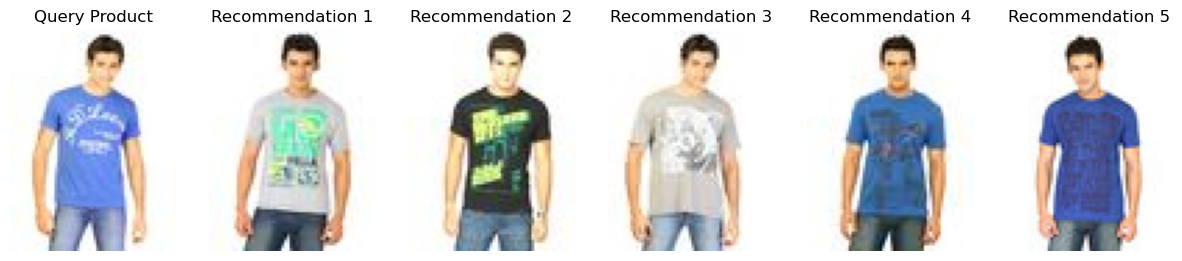

In [32]:
# ============================================================
# TASK 1 : TEST THE RECOMMENDATION ENGINE
# ============================================================
# Change the query index to test different products.
# ============================================================

query_index = 100

show_recommendations(query_index)

In [37]:
# ============================================================
# TASK 2: UNIQUE PRODUCT CATALOG CREATION
# ============================================================
# This task identifies duplicate or near-duplicate products
# using FAISS vector search and creates a unique product catalog.
# ============================================================

duplicate_threshold = 0.95

visited = set()
unique_products = []
duplicate_groups = []

for i in range(len(embeddings)):

    if i in visited:
        continue

    query = embeddings[i].reshape(1, -1)

    distances, indices = index.search(query, 10)

    group = []

    for dist, idx in zip(distances[0], indices[0]):

        if dist >= duplicate_threshold:

            group.append(idx)
            visited.add(idx)

    duplicate_groups.append(group)

    unique_products.append(i)

print("Total Products :", len(embeddings))
print("Unique Products :", len(unique_products))
print("Duplicate Groups :", len(duplicate_groups))

Total Products : 2526
Unique Products : 2417
Duplicate Groups : 2417


In [38]:
print("Sample Duplicate Groups\n")

for i, group in enumerate(duplicate_groups[:5]):

    print(f"Group {i+1} :", group)

Sample Duplicate Groups

Group 1 : [np.int64(0)]
Group 2 : [np.int64(1)]
Group 3 : [np.int64(2)]
Group 4 : [np.int64(3)]
Group 5 : [np.int64(4)]


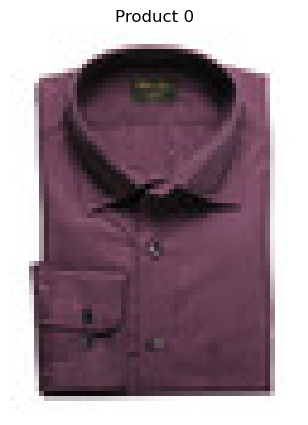

In [39]:
sample_group = duplicate_groups[0]

plt.figure(figsize=(15,5))

for i, idx in enumerate(sample_group):

    plt.subplot(1, len(sample_group), i+1)

    plt.imshow(Image.open(image_paths[idx]))

    plt.title(f"Product {idx}")

    plt.axis("off")

plt.show()

In [40]:
unique_catalog = df.iloc[unique_products]

print(unique_catalog.head())

print("\nFinal Unique Catalog Size :", len(unique_catalog))

      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  

Final Unique Catalog Size : 2417


In [42]:
# ============================================================
# TASK 3: REVERSE PRODUCT SEARCH USING TEXT
# ============================================================
# This task allows users to search products using text queries
# instead of images by using CLIP text embeddings.
# ============================================================

def get_text_embedding(text):

    text_tokens = tokenizer([text]).to(device)

    with torch.no_grad():

        text_features = model.encode_text(text_tokens)

        text_features /= text_features.norm(dim=-1, keepdim=True)

    return text_features.cpu().numpy()

In [43]:
def search_products(query, top_k=5):

    text_embedding = get_text_embedding(query)

    distances, indices = index.search(text_embedding, top_k)

    return indices[0]

In [44]:
def display_search_results(query):

    indices = search_products(query)

    plt.figure(figsize=(15,5))

    for i, idx in enumerate(indices):

        plt.subplot(1,5,i+1)

        img = Image.open(image_paths[idx])

        plt.imshow(img)

        plt.axis("off")

        plt.title(f"Match {i+1}")

    plt.suptitle(f"Search Query: {query}", fontsize=16)

    plt.show()

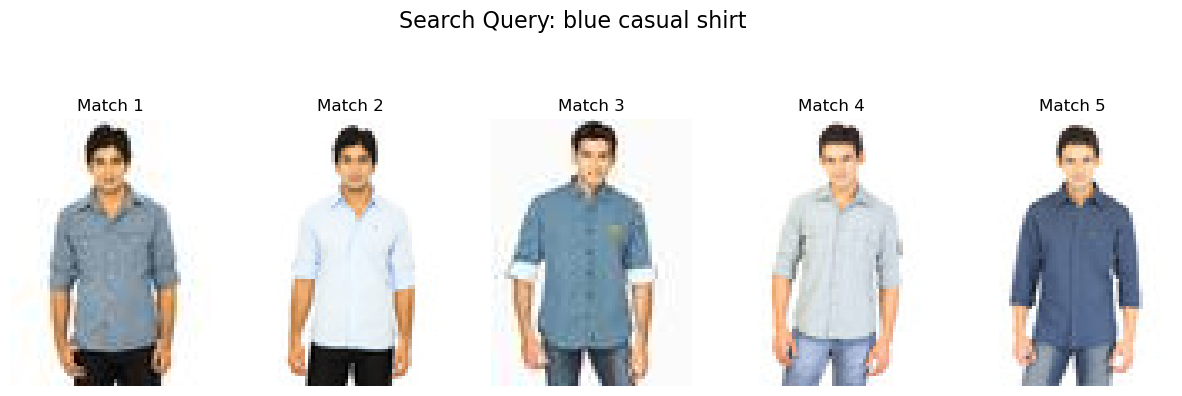

In [45]:
query = "blue casual shirt"

display_search_results(query)

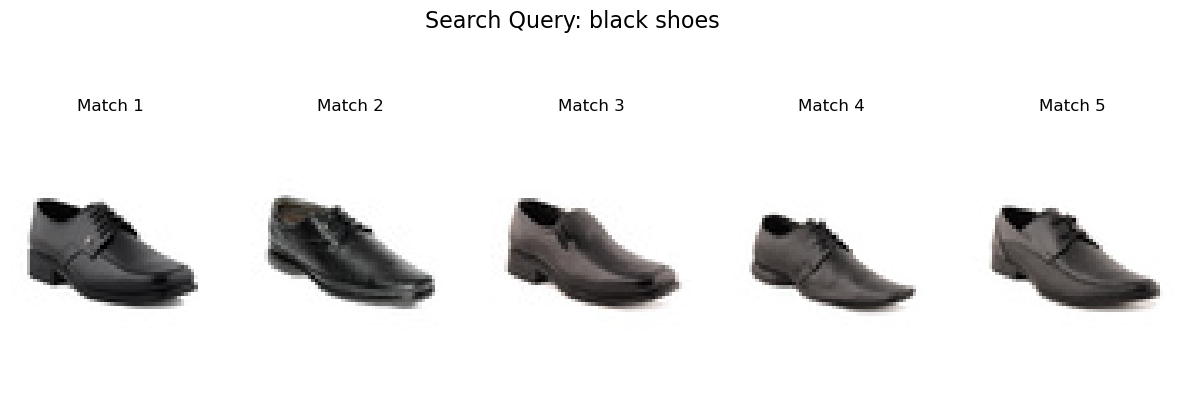

In [46]:
query = "black shoes"
display_search_results(query)

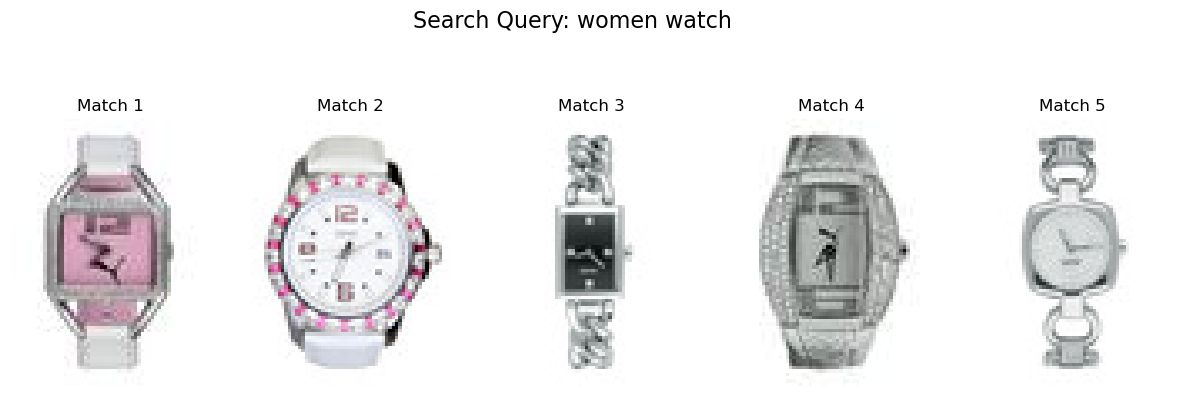

In [47]:
query = "women watch"
display_search_results(query)

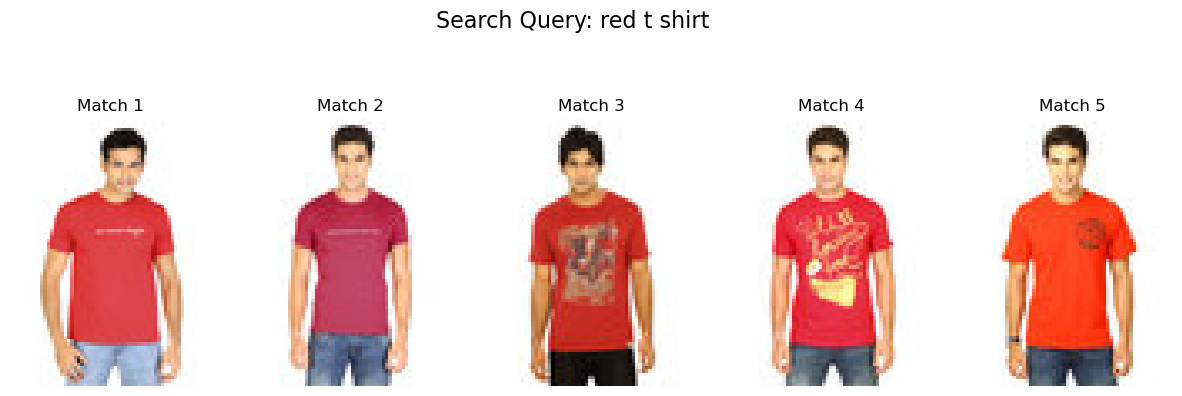

In [48]:
query = "red t shirt"
display_search_results(query)

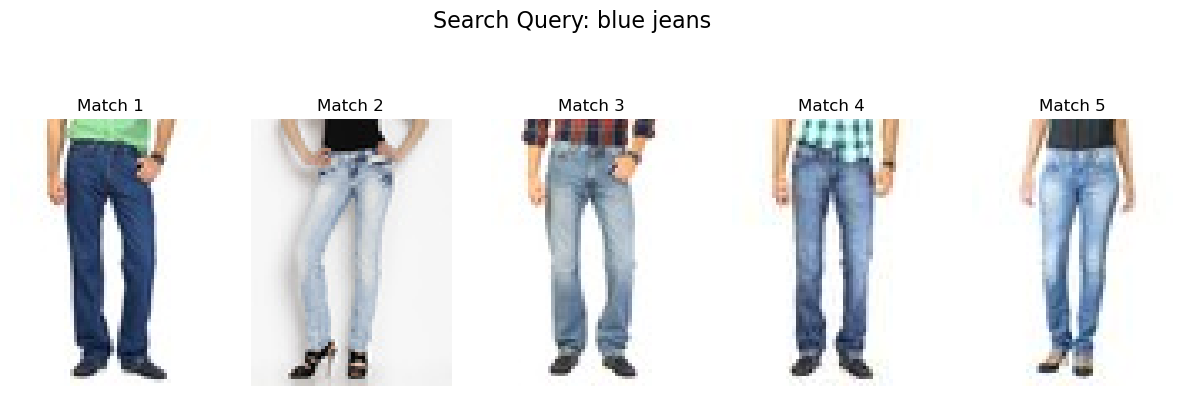

In [49]:
query = "blue jeans"
display_search_results(query)

In [53]:
# ============================================================
# BONUS FEATURE : SMART PRODUCT INSIGHTS
# ============================================================

def product_insight(product_index, metadata):

    product = metadata[product_index]

    print("\n========== PRODUCT INSIGHTS ==========\n")

    # Basic product info
    print("Product :", product["productDisplayName"])
    print("Category :", product["masterCategory"])
    print("Sub Category :", product["subCategory"])
    print("Gender :", product["gender"])
    print("Season :", product["season"])
    print("Usage :", product["usage"])

    # -----------------------------
    # Smart AI-like Insight Logic
    # -----------------------------

    season_advice = {
        "Summer": "lightweight and breathable clothing",
        "Winter": "warm and layered outfits",
        "Fall": "comfortable transitional wear",
        "Spring": "fresh and casual outfits"
    }

    usage_advice = {
        "Casual": "daily casual wear",
        "Sports": "active and flexible movement wear",
        "Formal": "professional and office wear",
        "Party": "stylish and fashionable occasions wear"
    }

    article = product.get("articleType", "this item").lower()
    usage = product.get("usage", "general").capitalize()
    season = product.get("season", "all seasons").capitalize()

    # Handle missing or unknown values safely
    season_text = season_advice.get(season, "suitable for general weather conditions")
    usage_text = usage_advice.get(usage, product.get("usage", "general").lower())

    print("\n⭐ AI Insight:")

    print(
        f"This {article} is designed for {usage_text}, "
        f"making it ideal for {season.lower()} season. "
        f"It works best as {season_text}."
    )

In [55]:
def find_product_by_name(name, metadata):
    for i, product in enumerate(metadata):
        if name.lower() in product["productDisplayName"].lower():
            return i
    return None

user_input = input("Enter product name: ")

index = find_product_by_name(user_input, metadata)

if index is not None:
    product_insight(index, metadata)
else:
    print("❌ Product not found")

Enter product name:  5



========== PRODUCT INSIGHTS ==========

Product : Puma Men Star Dust 145 White Watches
Category : Accessories
Sub Category : Watches
Gender : Men
Season : Winter
Usage : Casual

⭐ AI Insight:
This watches is designed for daily casual wear, making it ideal for winter season. It works best as warm and layered outfits.
